In [ ]:
# TP 4 : Pont de Fremont 
#Eléonore Veyron

URL = "https://data.seattle.gov/api/views/65db-xm6k/rows.csv?accessType=DOWNLOAD"


import pandas as pd
import matplotlib.pyplot as plt

# on a déja le fichier en local
local_file = "fremont.csv"

from pathlib import Path

if Path(local_file).exists():
    print(f"le fichier {local_file} est déjà là")
else:
    print(f"allons chercher le fichier {local_file}")

    import requests
    req = requests.get(URL)
    print(req.status_code)

    with open(local_file, 'w') as writer:
        writer.write(req.text)

!head $local_file
# version naïve
data = pd.read_csv(local_file)
data.shape
data.head()


le fichier fremont.csv est déjà là
Date,Fremont Bridge Total,Fremont Bridge East Sidewalk,Fremont Bridge West Sidewalk
08/01/2022 12:00:00 AM,23,7,16
08/01/2022 01:00:00 AM,12,5,7
08/01/2022 02:00:00 AM,3,0,3
08/01/2022 03:00:00 AM,5,2,3
08/01/2022 04:00:00 AM,10,2,8
08/01/2022 05:00:00 AM,27,5,22
08/01/2022 06:00:00 AM,100,43,57
08/01/2022 07:00:00 AM,219,90,129
08/01/2022 08:00:00 AM,335,143,192


,Date,Fremont Bridge Total,Fremont Bridge East Sidewalk,Fremont Bridge West Sidewalk
0,08/01/2022 12:00:00 AM,23.0,7.0,16.0
1,08/01/2022 01:00:00 AM,12.0,5.0,7.0
2,08/01/2022 02:00:00 AM,3.0,0.0,3.0
3,08/01/2022 03:00:00 AM,5.0,2.0,3.0
4,08/01/2022 04:00:00 AM,10.0,2.0,8.0


In [ ]:
#1 Doublons
!grep '01/01/2014 12:00:00 AM' $local_file

# on se débarrase des lignes en double 
data1 = data.drop_duplicates()

# taille du tableau  
print("La taille de data2",data.shape)
print("La taille de data1", data1.shape)

01/01/2014 12:00:00 AM,23,5,18
01/01/2014 12:00:00 AM,23,5,18
La taille de data2 (175200, 4)
La taille de data1 (87600, 4)


In [ ]:
#2 Echauffement : le DatatimeIndex

sample_dates = pd.to_datetime([
    "2024-01-15 08:00:00",
    "2024-01-20 17:30:00",
    "2024-02-03 12:00:00",
])

# 1. Type de sample_datas : 
print("Le type de sample_dates est", type(sample_dates))
# 2. 
print(sample_dates.date) #donne la partie date du tableau
print(sample_dates.time) #donne la partie horraires du tableau
print(sample_dates.dayofweek) 

# 3. Garder les dates postérieures ou égales au 20.01.24
reduit = sample_dates[sample_dates>="2024-01-20 00:00:00"]
print(reduit)

#4 Comment ne garder que les dates de janvier 2024
reduit2 = sample_dates[(sample_dates>="2024-01-01 00:00:00") & (sample_dates<="2024-01-31 23:59:59")]
print(reduit2)


Le type de sample_dates est <class 'pandas.DatetimeIndex'>
[datetime.date(2024, 1, 15) datetime.date(2024, 1, 20)
 datetime.date(2024, 2, 3)]
[datetime.time(8, 0) datetime.time(17, 30) datetime.time(12, 0)]
Index([0, 5, 5], dtype='int32')
DatetimeIndex(['2024-01-20 17:30:00', '2024-02-03 12:00:00'], dtype='datetime64[us]', freq=None)
DatetimeIndex(['2024-01-15 08:00:00', '2024-01-20 17:30:00'], dtype='datetime64[us]', freq=None)


AttributeError: 'DatetimeIndex' object has no attribute 'head'

In [ ]:
# 3 Parser les dates 
# intéressant aussi, pour voir notamment les points manquants
data.info()
data.dtypes
#format :mois/jour/année heure:minute:seconde AM/PM

data.index = pd.to_datetime(data.Date)

print(data.head())

del data["Date"] #supprime une colonne

<class 'pandas.DataFrame'>
RangeIndex: 175200 entries, 0 to 175199
Data columns (total 4 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Date                          175200 non-null  str    
 1   Fremont Bridge Total          175172 non-null  float64
 2   Fremont Bridge East Sidewalk  175172 non-null  float64
 3   Fremont Bridge West Sidewalk  175172 non-null  float64
dtypes: float64(3), str(1)
memory usage: 5.3 MB


C:\Users\eleon\AppData\Local\Temp\ipykernel_17956\842220100.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data.index = pd.to_datetime(data.Date)


In [90]:
#4 Renommons les colonnes

data.columns = [
    'Total',
    'West',
    'East'
]

#5 Données manquantes et extension types

#5.1 Affichons les lignes qui contiennent au moins une valeur manquante : 

print("Lignes avec valeurs manquantes")
data.dropna()

data.fillna(0)
#data=data.convert_dtypes(convert_integre=True)
print(data.head())

%matplotlib inline
sns.set(rc={'figure.figsize': (12, 4)})


Lignes avec valeurs manquantes
                     Total  West  East
Date                                  
2022-08-01 00:00:00   23.0   7.0  16.0
2022-08-01 01:00:00   12.0   5.0   7.0
2022-08-01 02:00:00    3.0   0.0   3.0
2022-08-01 03:00:00    5.0   2.0   3.0
2022-08-01 04:00:00   10.0   2.0   8.0


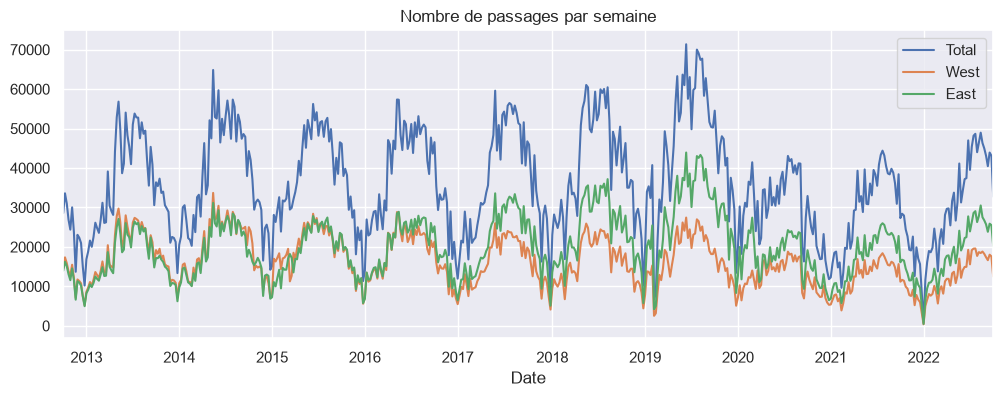

True


In [95]:
#6 Resample() : changer la fréquence temporelle 

#Nb total de passage par semaine 
data.resample("1W").sum().plot( 
    figsize=(12,4),
    title="Nombre de passages par semaine")

plt.show()

if data.shape[0] >= data.resample("1W").sum().shape[0] *7*24:
    print(True)
else:
    print(False)

In [ ]:
ax = annual.plot( figsize = (12,4), title = 'Passages cumulés sur une année glissante)